
===== STICK MODEL RESULTS =====

Range -53.700 to -52.700 m
  Equivalent Drag Diameter  : 35.358 m
  Equivalent Inertia Diam.  : 9.616 m
  Force in Range            : 121594.07 N
  Moment about SWL          : -6468801.71 Nm

Range -52.700 to -27.386 m
  Equivalent Drag Diameter  : 35.358 m
  Equivalent Inertia Diam.  : 9.616 m
  Force in Range            : 3273257.47 N
  Moment about SWL          : -129858157.17 Nm

Range -27.386 to -7.173 m
  Equivalent Drag Diameter  : 35.358 m
  Equivalent Inertia Diam.  : 9.616 m
  Force in Range            : 3420088.90 N
  Moment about SWL          : -57154153.37 Nm

Range -7.173 to 8.967 m
  Equivalent Drag Diameter  : 35.358 m
  Equivalent Inertia Diam.  : 9.616 m
  Force in Range            : 3886669.49 N
  Moment about SWL          : 5369114.15 Nm

Range 8.967 to 9.967 m
  Equivalent Drag Diameter  : 35.358 m
  Equivalent Inertia Diam.  : 9.616 m
  Force in Range            : 291664.73 N
  Moment about SWL          : 2761781.62 Nm

Total Base

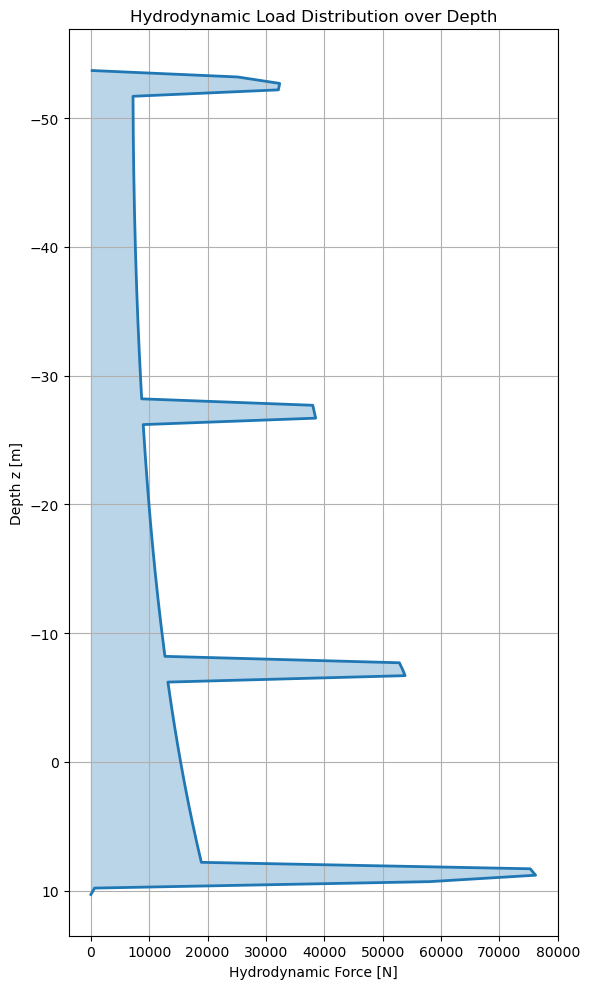

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# ------------------- INPUT SECTION -------------------
# =====================================================

H = 13.6          # wave height (m)
T = 15.0          # wave period (s)
h = 53.7          # water depth (m, SWL)
phase = np.pi/4

rho = 1025
CD = 1.0
CM = 2.0

# Node coordinates in soil reference (z=0 at seabed)
nodes = {
    1:(12.815,12.815,0.0),2:(12.815,-12.815,0.0),
    3:(-12.815,-12.815,0.0),4:(-12.815,12.815,0.0),
    5:(12.765,12.765,1.0),6:(12.765,-12.765,1.0),
    7:(-12.765,-12.765,1.0),8:(-12.765,12.765,1.0),
    9:(10.193,10.193,26.314),10:(10.193,-10.193,26.314),
    11:(-10.193,-10.193,26.314),12:(-10.193,10.193,26.314),
    13:(8.070,8.070,46.527),14:(8.070,-8.070,46.527),
    15:(-8.070,-8.070,46.527),16:(-8.070,8.070,46.527),
    17:(6.444,6.444,62.667),18:(6.444,-6.444,62.667),
    19:(-6.444,-6.444,62.667),20:(-6.444,6.444,62.667),
    21:(6.404,6.404,63.667),22:(6.404,-6.404,63.667),
    23:(-6.404,-6.404,63.667),24:(-6.404,6.404,63.667)
}

# Members (cylindrical elements)
members = [
    {'start':5,'end':6,'D':1.5},{'start':6,'end':7,'D':1.5},
    {'start':7,'end':8,'D':1.5},{'start':8,'end':5,'D':1.5},
    {'start':5,'end':10,'D':1.2},{'start':6,'end':11,'D':1.2},
    {'start':7,'end':12,'D':1.2},{'start':8,'end':9,'D':1.2},
    {'start':9,'end':10,'D':1.5},{'start':10,'end':11,'D':1.5},
    {'start':11,'end':12,'D':1.5},{'start':12,'end':9,'D':1.5},
    {'start':10,'end':13,'D':1.2},{'start':11,'end':14,'D':1.2},
    {'start':12,'end':15,'D':1.2},{'start':9,'end':16,'D':1.2},
    {'start':13,'end':14,'D':1.5},{'start':14,'end':15,'D':1.5},
    {'start':15,'end':16,'D':1.5},{'start':16,'end':13,'D':1.5},
    {'start':13,'end':18,'D':1.2},{'start':14,'end':19,'D':1.2},
    {'start':15,'end':20,'D':1.2},{'start':16,'end':17,'D':1.2},
    {'start':17,'end':18,'D':1.5},{'start':18,'end':19,'D':1.5},
    {'start':19,'end':20,'D':1.5},{'start':20,'end':17,'D':1.5},
    {'start':1,'end':5,'D':1.0},{'start':5,'end':9,'D':1.0},
    {'start':9,'end':13,'D':1.0},{'start':13,'end':17,'D':1.0},
    {'start':17,'end':21,'D':1.0},{'start':2,'end':6,'D':1.0},
    {'start':6,'end':10,'D':1.0},{'start':10,'end':14,'D':1.0},
    {'start':14,'end':18,'D':1.0},{'start':18,'end':22,'D':1.0},
    {'start':3,'end':7,'D':1.0},{'start':7,'end':11,'D':1.0},
    {'start':11,'end':15,'D':1.0},{'start':15,'end':19,'D':1.0},
    {'start':19,'end':23,'D':1.0}
]

# =====================================================
# ------------------- RANGES --------------------------
# =====================================================
# SWL coordinates (z_soil - h)
ranges = [
    (0.0 - h, 1.0 - h),         # 1 m above seabed
    (1.0 - h, 26.314 - h),      # lower vertical frame
    (26.314 - h, 46.527 - h),   # mid vertical frame
    (46.527 - h, 62.667 - h),   # upper vertical frame
    (62.667 - h, 63.667 - h)    # top horizontal member
]

# =====================================================
# ----------------- COMPUTATION PART -----------------
# =====================================================

g = 9.81

def wave_number(T,h):
    omega = 2*np.pi/T
    k = omega**2/g
    for _ in range(100):
        f = g*k*np.tanh(k*h) - omega**2
        df = g*np.tanh(k*h) + g*k*h*(1/np.cosh(k*h))**2
        k -= f/df
    return k

def airy_kinematics(z,H,T,h,phase):
    omega = 2*np.pi/T
    k = wave_number(T,h)
    a = H/2
    u = a*omega*np.cosh(k*(z+h))/np.sinh(k*h)*np.cos(phase)
    a_x = a*omega**2*np.cosh(k*(z+h))/np.sinh(k*h)*np.sin(phase)
    return u,a_x

def wheeler_z(z,zeta,h):
    return ((z+h)/(h+zeta))*h - h

def stick_model():
    results=[]
    for zU,zL in ranges:
        E0 = abs(zU-zL)
        Dde_sum = 0
        Die_sq_sum = 0

        for m in members:
            xi,yi,zi_raw = nodes[m['start']]
            xj,yj,zj_raw = nodes[m['end']]
            zi = zi_raw - h
            zj = zj_raw - h

            D = m['D']
            dx = xj - xi
            dy = yj - yi
            dz = zj - zi
            L = np.sqrt(dx**2 + dy**2 + dz**2)
            if L==0: continue

            p = np.sqrt(dx**2 + dy**2)
            q = (p*D)/L
            Dde_sum += q
            Die_sq_sum += (q*D)**2

        Die_sum = np.sqrt(Die_sq_sum)
        z_vals = [zU,(zU+zL)/2,zL]
        f_vals = []

        for z in z_vals:
            zeta = H/2*np.cos(phase)
            z_stretch = wheeler_z(z,zeta,h)
            u,a_x = airy_kinematics(z_stretch,H,T,h,phase)
            f_drag = 0.5*rho*CD*Dde_sum*u*abs(u)
            f_inertia = rho*CM*(np.pi/4)*Die_sum**2*a_x
            f_vals.append(f_drag+f_inertia)

        FR = E0/6*(f_vals[0]+4*f_vals[1]+f_vals[2])
        MR = E0/6*(f_vals[0]*zU+4*f_vals[1]*((zU+zL)/2)+f_vals[2]*zL)
        results.append({'zU':zU,'zL':zL,'Force':FR,'Moment_SWL':MR,'Dde':Dde_sum,'Die':Die_sum})

    F_total = sum(r['Force'] for r in results)
    M_total = sum(r['Moment_SWL'] for r in results)
    return F_total,M_total,results

def hydrodynamic_distribution(nodes,members,H,T,h,phase=phase,dz=0.5):
    z_min = min(zi-h for _,_,zi in nodes.values())
    z_max = max(zi-h for _,_,zi in nodes.values())
    z_grid = np.arange(z_min,z_max+dz,dz)
    distribution=[]

    for z in z_grid:
        Dde_sum = 0
        Die_sq_sum = 0
        for m in members:
            xi,yi,zi_raw = nodes[m['start']]
            xj,yj,zj_raw = nodes[m['end']]
            zi = zi_raw - h
            zj = zj_raw - h
            D = m['D']
            dx = xj - xi
            dy = yj - yi
            dz_m = zj - zi
            L = np.sqrt(dx**2 + dy**2 + dz_m**2)
            if L==0: continue
            p = np.sqrt(dx**2 + dy**2)

            # Horizontal members produce rectangular jumps
            if abs(dz_m) < 1e-6 and abs(z-zi) <= D/2:
                q = (p*D)/L
                Dde_sum += q
                Die_sq_sum += (q*D)**2
            # Vertical or inclined members
            elif min(zi,zj) <= z <= max(zi,zj):
                q = (p*D)/L
                Dde_sum += q
                Die_sq_sum += (q*D)**2

        Die_sum = np.sqrt(Die_sq_sum)
        zeta = H/2*np.cos(phase)
        z_stretch = wheeler_z(z,zeta,h)
        u,a_x = airy_kinematics(z_stretch,H,T,h,phase)
        f_drag = 0.5*rho*CD*Dde_sum*u*abs(u)
        f_inertia = rho*CM*(np.pi/4)*Die_sum**2*a_x
        distribution.append({'z':z,'Force':f_drag+f_inertia})

    return distribution

# =====================================================
# ---------------------- OUTPUT -----------------------
# =====================================================

F_total,M_total,results = stick_model()

print("\n===== STICK MODEL RESULTS =====\n")
for r in results:
    print(f"Range {r['zU']:.3f} to {r['zL']:.3f} m")
    print(f"  Equivalent Drag Diameter  : {r['Dde']:.3f} m")
    print(f"  Equivalent Inertia Diam.  : {r['Die']:.3f} m")
    print(f"  Force in Range            : {r['Force']:.2f} N")
    print(f"  Moment about SWL          : {r['Moment_SWL']:.2f} Nm\n")
print("================================")
print(f"Total Base Shear  : {F_total:.2f} N")
print(f"Total Base Moment : {M_total:.2f} Nm")
print("================================\n")

force_distribution = hydrodynamic_distribution(nodes,members,H,T,h,phase=phase)

z_vals = [fd['z'] for fd in force_distribution]
forces = [fd['Force'] for fd in force_distribution]

plt.figure(figsize=(6,10))
plt.plot(forces,z_vals,linewidth=2)
plt.fill_betweenx(z_vals,0,forces,alpha=0.3)
plt.gca().invert_yaxis()
plt.xlabel('Hydrodynamic Force [N]')
plt.ylabel('Depth z [m]')
plt.title('Hydrodynamic Load Distribution over Depth')
plt.grid(True)
plt.tight_layout()
plt.show()